# 03 · Cell-type annotation

**Phase 3 of the project** ([PROJECT_PLAN.md](../PROJECT_PLAN.md)).

Annotate the integrated cells with major cell-type labels, then benchmark
those labels against LuCA's published `cell_type_major` annotation.

**Approach.** Notebook 02 produced a batch-corrected `X_scVI` embedding. Here we:

1. **Leiden-cluster** the `X_scVI` neighbour graph into fine clusters.
2. Score every cell against nine **canonical lineage marker signatures**
   (epithelial, T, NK, B, plasma, myeloid, mast, endothelial, fibroblast).
3. Assign each Leiden cluster to the lineage it scores highest on, and
   propagate that label to every cell in the cluster.
4. **Benchmark** our labels against Salcher 2022's expert `cell_type_major`
   annotation — confusion matrix, overall agreement, and Adjusted Rand Index.

**Why cluster-then-score, not score-per-cell.** Marker-signature scores are
noisy at single-cell resolution because of dropout. Assigning at the cluster
level pools that noise: a Leiden cluster is a group of transcriptionally
similar cells, so its *mean* signature score is a far more stable estimate
than any single cell's.

**Why this is not circular.** LuCA's `cell_type_major` was produced by the
atlas authors with their own pipeline. We never feed it into clustering or
scoring — it is held out purely as an answer key. Agreement is therefore a
genuine, if coarse, external check on the annotation.

**Inputs**: `data/processed/luca_integrated.h5ad` (`.X` log-normalized,
`obsm["X_scVI"]`, `obsm["X_umap"]`, neighbour graph in `.obsp`).

**Outputs**:
- `data/processed/luca_annotated.h5ad` — adds `obs["leiden"]`,
  `obs["cell_type_pred"]`, and per-lineage `obs["score_*"]`
- `figures/umap_leiden.png`, `figures/celltype_score_heatmap.png`,
  `figures/marker_dotplot.png`, `figures/umap_celltype_pred.png`,
  `figures/annotation_confusion_matrix.png`, `figures/umap_annotation_compare.png`
- `figures/annotation_metrics.csv` (tracked in git)

**Time budget**: ~5–10 min — loading the 1.2 GB h5ad and Leiden are the only
non-trivial cells; there is no model training in this notebook.

## 1. Setup

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repo root. Launch Jupyter from inside the repo (standard
# workflow); if launching from elsewhere, set the REPO_ROOT env variable.
def _find_repo_root():
    env = os.environ.get("REPO_ROOT")
    if env and (Path(env) / "src" / "subsample.py").exists():
        return Path(env).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "subsample.py").exists():
            return p.resolve()
    raise RuntimeError(
        "Repo root not found. Launch Jupyter from inside the repository, "
        "or set the REPO_ROOT environment variable."
    )

ROOT = _find_repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


def relpath(p):
    """Path relative to the repo root - keeps printed paths portable."""
    p = Path(p)
    try:
        return p.relative_to(ROOT)
    except ValueError:
        return p.name


from src.data_io import load_adata, save_adata

FIG_DIR = ROOT / "figures"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

# scanpy's sc.pl.*(save=...) writes into sc.settings.figdir, prefixing the
# filename with the plot type (e.g. save="_leiden.png" -> umap_leiden.png).
# Use a *relative* path so scanpy's save messages stay portable (the notebook
# has already chdir'd to the repo root above).
sc.settings.figdir = "figures"
sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, frameon=False)

RANDOM_STATE = 0
print(f"repo root: {ROOT.name}/")
print(f"scanpy {sc.__version__} · anndata {ad.__version__}")

repo root: scrnaseq-tumor-microenvironment/
scanpy 1.11.5 · anndata 0.12.14


## 2. Load the integrated AnnData + pre-flight

Load notebook 02's output and confirm it carries what this notebook needs:
the `X_scVI` embedding, the neighbour graph built on it, and the published
`cell_type_major` labels we will benchmark against.

In [2]:
adata = load_adata("processed/luca_integrated.h5ad")
print(adata)
print()

# Pre-flight: confirm notebook 02's outputs are present.
assert "X_scVI" in adata.obsm, "Missing obsm['X_scVI'] - run notebook 02 first."
assert "cell_type_major" in adata.obs, \
    "Missing obs['cell_type_major'] - needed as the benchmark answer key."

has_graph = "neighbors" in adata.uns and "connectivities" in adata.obsp
print(f"X_scVI embedding:   {adata.obsm['X_scVI'].shape}")
print(f"UMAP precomputed:   {'X_umap' in adata.obsm}")
print(f"Neighbour graph:    {'present (reused)' if has_graph else 'absent (will recompute)'}")
print(f"Benchmark labels:   obs['cell_type_major'] - "
      f"{adata.obs['cell_type_major'].nunique()} categories")
print()
print("Published cell_type_major categories:")
print(adata.obs["cell_type_major"].value_counts().to_string())

AnnData object with n_obs × n_vars = 92013 × 17764
    obs: 'study', 'dataset', 'disease', 'sample', 'donor_id', 'cell_type', 'cell_type_major', 'ann_coarse', 'ann_fine', 'ever_smoker', 'sex', 'age', 'tumor_stage', 'uicc_stage', 'origin', 'origin_fine', 'platform', 'assay', 'n_genes_by_counts', 'total_counts', 'pct_counts_mito', 'total_counts_mito', 'doublet_status', 'EGFR_mutation', 'KRAS_mutation', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation'
    var: 'feature_biotype', 'feature_is_filtered', 'feature_length', 'feature_name', 'feature_reference', 'feature_type', 'is_highly_variable', 'mean_counts', 'mito', 'n_cells_by_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_major_colors', 'disease_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'study_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'normalized_atlas'
    obsp: 'connectivities', 'distances'

X_scVI e

### Gene identifiers — use symbols, not Ensembl IDs

The LuCA atlas follows the CELLxGENE convention: `var_names` are **Ensembl
gene IDs** (`ENSG00000121410`, …) and the human-readable HGNC **symbols**
(`EPCAM`, `CD3D`, …) live in `var["feature_name"]`. Marker-gene scoring needs
symbols, so we switch the index to `feature_name` and keep the Ensembl IDs in
`var["ensembl_id"]` for traceability. `var_names_make_unique()` disambiguates
the handful of symbols that map from more than one Ensembl ID.

This cell is a no-op if `var_names` are already symbols, so it is safe to
re-run.

In [3]:
if "feature_name" in adata.var.columns:
    adata.var["ensembl_id"] = np.asarray(adata.var_names)
    adata.var_names = adata.var["feature_name"].astype(str)
    adata.var.index.name = None      # else index name clashes with the column on save
    adata.var_names_make_unique()
    adata.var = adata.var.drop(columns="feature_name")   # now redundant with the index
    print(f"var_names switched to gene symbols. Examples: "
          f"{list(adata.var_names[:5])}")
else:
    print("var['feature_name'] not found - assuming var_names are already "
          "gene symbols.")

# Sanity check: a few universal genes should now resolve.
for g in ["EPCAM", "CD3D", "PECAM1"]:
    print(f"  {g}: {'present' if g in adata.var_names else 'MISSING'}")

var_names switched to gene symbols. Examples: ['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'A2ML1']
  EPCAM: present
  CD3D: present
  PECAM1: present


## 3. Leiden clustering on the scVI latent space

Notebook 02 already built a KNN graph on `X_scVI` (and it travels inside the
h5ad), so we cluster that graph directly. We deliberately **over-cluster**
relative to the nine lineages we are about to assign: at `resolution=1.0` a
92K-cell atlas yields roughly 15–25 clusters, so most lineages will be split
across several clusters. That is fine — and useful. Fine clusters let a
single lineage's distinct states (e.g. CD4 vs CD8 T cells) each land on a
clean marker signal, and the assignment step in section 5 collapses them
back to the coarse label.

`flavor="igraph"` selects scanpy ≥1.10's fast Leiden backend.

In [4]:
# The neighbour graph was built on X_scVI in notebook 02 and is stored in the
# h5ad. Recompute only if it is missing (e.g. an older integrated file).
if not has_graph:
    print("Neighbour graph absent - recomputing on X_scVI ...")
    sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15,
                    random_state=RANDOM_STATE)

LEIDEN_RESOLUTION = 1.0
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RESOLUTION,
    key_added="leiden",
    flavor="igraph",        # scanpy >=1.10 fast backend
    n_iterations=2,
    directed=False,
    random_state=RANDOM_STATE,
)
n_clusters = adata.obs["leiden"].nunique()
print(f"Leiden (resolution={LEIDEN_RESOLUTION}): {n_clusters} clusters")
print()
print("Cells per cluster:")
print(adata.obs["leiden"].value_counts().sort_index().to_string())

Leiden (resolution=1.0): 38 clusters

Cells per cluster:
leiden
0       662
1      4175
2      6007
3     10401
4      6251
5        85
6       526
7      2048
8       870
9      1978
10     5592
11     8310
12     1609
13    10540
14      794
15     1679
16        6
17     3079
18     4939
19     4344
20      679
21       92
22     1237
23      183
24      353
25     1174
26     5016
27     1601
28     3522
29      310
30      444
31     1619
32      830
33       17
34      512
35       83
36      289
37      157


In [5]:
sc.pl.umap(
    adata, color="leiden", legend_loc="on data", legend_fontsize=7,
    title=f"Leiden clusters (resolution={LEIDEN_RESOLUTION})",
    size=4, save="_leiden.png", show=False,
)
plt.show()

## 4. Canonical lineage marker signatures

Nine signatures cover the major compartments of a lung tumour
microenvironment. Each is a **multi-gene set**, not a single marker, so the
score is robust to dropout in any one gene. `sc.tl.score_genes` computes, per
cell, the mean expression of the signature minus a control set sampled from
genes in matched expression bins — so a high score means "enriched for this
lineage *above what ambient expression would predict*."

We score on `.X` (log-normalized) with `use_raw=False`. Any marker gene not
present in this subsample's `var_names` is dropped, with a printed note.

In [6]:
# Canonical markers for the major lineages of a lung tumour microenvironment.
MARKERS = {
    "Epithelial":  ["EPCAM", "KRT8", "KRT18", "KRT19", "CDH1", "SFTPB", "SFTPC", "SCGB1A1"],
    "T cell":      ["CD3D", "CD3E", "CD3G", "TRAC", "TRBC2", "CD2", "IL7R"],
    "NK cell":     ["NKG7", "GNLY", "KLRD1", "KLRF1", "NCAM1", "PRF1"],
    "B cell":      ["MS4A1", "CD79A", "CD79B", "CD19", "BANK1"],
    "Plasma cell": ["MZB1", "JCHAIN", "IGHG1", "XBP1", "DERL3", "SDC1"],
    "Myeloid":     ["LYZ", "CD68", "CD14", "FCGR3A", "ITGAM", "C1QA", "C1QB", "AIF1", "MARCO"],
    "Mast cell":   ["TPSAB1", "TPSB2", "CPA3", "MS4A2", "KIT"],
    "Endothelial": ["PECAM1", "VWF", "CLDN5", "CDH5", "FLT1", "RAMP2"],
    "Fibroblast":  ["COL1A1", "COL1A2", "COL3A1", "DCN", "LUM", "PDGFRB", "BGN"],
}

# Keep only genes actually present in this subsample's var_names.
present = set(adata.var_names)
MARKERS_PRESENT = {}
for lineage, genes in MARKERS.items():
    found = [g for g in genes if g in present]
    missing = [g for g in genes if g not in present]
    MARKERS_PRESENT[lineage] = found
    flag = f"  (missing: {', '.join(missing)})" if missing else ""
    print(f"{lineage:12s} {len(found)}/{len(genes)} genes{flag}")
    assert found, f"No marker genes found for {lineage} - check gene-name convention."

Epithelial   8/8 genes
T cell       7/7 genes
NK cell      6/6 genes
B cell       5/5 genes
Plasma cell  6/6 genes
Myeloid      9/9 genes
Mast cell    5/5 genes
Endothelial  6/6 genes
Fibroblast   7/7 genes


In [7]:
# Per-cell signature scores -> adata.obs["score_<lineage>"].
for lineage, genes in MARKERS_PRESENT.items():
    sc.tl.score_genes(
        adata, gene_list=genes,
        score_name=f"score_{lineage}",
        use_raw=False, random_state=RANDOM_STATE,
    )

score_cols = [f"score_{l}" for l in MARKERS_PRESENT]
print("Per-cell signature scores added to adata.obs:")
print(adata.obs[score_cols].describe().round(3).T)

Per-cell signature scores added to adata.obs:
                     count   mean    std    min    25%    50%    75%    max
score_Epithelial   92013.0 -0.024  0.640 -0.754 -0.412 -0.282  0.064  3.413
score_T cell       92013.0 -0.331  0.788 -1.351 -0.882 -0.634 -0.081  2.977
score_NK cell      92013.0 -0.109  0.621 -0.642 -0.407 -0.310 -0.185  3.360
score_B cell       92013.0  0.002  0.269 -0.299 -0.085 -0.054 -0.027  2.967
score_Plasma cell  92013.0 -0.092  0.409 -0.547 -0.295 -0.205 -0.011  4.217
score_Myeloid      92013.0  0.055  0.742 -0.940 -0.483 -0.266  0.415  3.088
score_Mast cell    92013.0 -0.001  0.451 -0.312 -0.098 -0.067 -0.040  5.198
score_Endothelial  92013.0 -0.015  0.455 -0.448 -0.193 -0.133 -0.067  3.593
score_Fibroblast   92013.0  0.009  0.418 -0.328 -0.097 -0.065 -0.034  4.636


## 5. Assign each Leiden cluster to a lineage

For each Leiden cluster we take the **mean signature score per lineage**,
giving a (cluster × lineage) matrix.

One subtlety: the nine signatures differ in size and in baseline expression,
so their raw scores are **not comparable across lineages** — the epithelial
signature simply runs higher than the mast-cell signature everywhere. To
make them comparable we **z-score each lineage down its column** (across
clusters). The question then becomes "which clusters are most enriched for
this lineage, relative to other clusters" — and the per-cluster argmax of the
z-scored matrix is a fair assignment.

We also report a **margin** (gap between the top and second lineage). A small
margin flags a cluster whose identity is ambiguous and worth eyeballing in
the heatmap below.

In [8]:
# Mean signature score per Leiden cluster -> (cluster x lineage) matrix.
cluster_scores = adata.obs.groupby("leiden", observed=True)[score_cols].mean()
cluster_scores.columns = [c.replace("score_", "") for c in cluster_scores.columns]

# z-score each lineage DOWN its column so signatures are comparable.
z = (cluster_scores - cluster_scores.mean()) / cluster_scores.std(ddof=0)

# Assign each cluster to its top-scoring lineage.
cluster_to_lineage = z.idxmax(axis=1)
adata.obs["cell_type_pred"] = (
    adata.obs["leiden"].map(cluster_to_lineage).astype("category")
)

# Diagnostics: top lineage, its z-score, and the margin over 2nd place.
z_sorted = np.sort(z.values, axis=1)
assign = pd.DataFrame({
    "lineage": cluster_to_lineage,
    "z_top": z.max(axis=1).round(2),
    "margin": (z_sorted[:, -1] - z_sorted[:, -2]).round(2),
    "n_cells": adata.obs["leiden"].value_counts(),
})
print(assign.sort_values("lineage").to_string())
print()
ambiguous = assign[assign["margin"] < 0.5]
if len(ambiguous):
    print(f"Low-margin clusters (<0.5) - eyeball these in the heatmap: "
          f"{sorted(ambiguous.index, key=int)}")
else:
    print("All clusters assigned with a comfortable margin (>=0.5).")
print()
print("Predicted cell-type composition:")
print(adata.obs["cell_type_pred"].value_counts().to_string())

            lineage  z_top  margin  n_cells
leiden                                     
37           B cell  -0.24    0.04      157
17           B cell   5.82    5.79     3079
33      Endothelial   0.76    0.23       17
26      Endothelial   5.33    5.17     5016
14      Endothelial   2.43    2.58      794
16      Endothelial  -0.23    0.01        6
34       Epithelial   1.06    0.63      512
29       Epithelial   0.41    0.56      310
28       Epithelial   0.39    0.42     3522
25       Epithelial   0.99    1.20     1174
24       Epithelial   2.18    2.36      353
23       Epithelial   0.04    0.13      183
22       Epithelial   0.84    0.62     1237
20       Epithelial   0.07    0.18      679
19       Epithelial   1.56    1.32     4344
36       Epithelial   1.01    0.62      289
18       Epithelial   2.62    2.50     4939
8        Epithelial   2.01    1.80      870
6        Epithelial   2.10    0.59      526
27       Fibroblast   5.24    5.46     1601
32       Fibroblast   2.70    2.

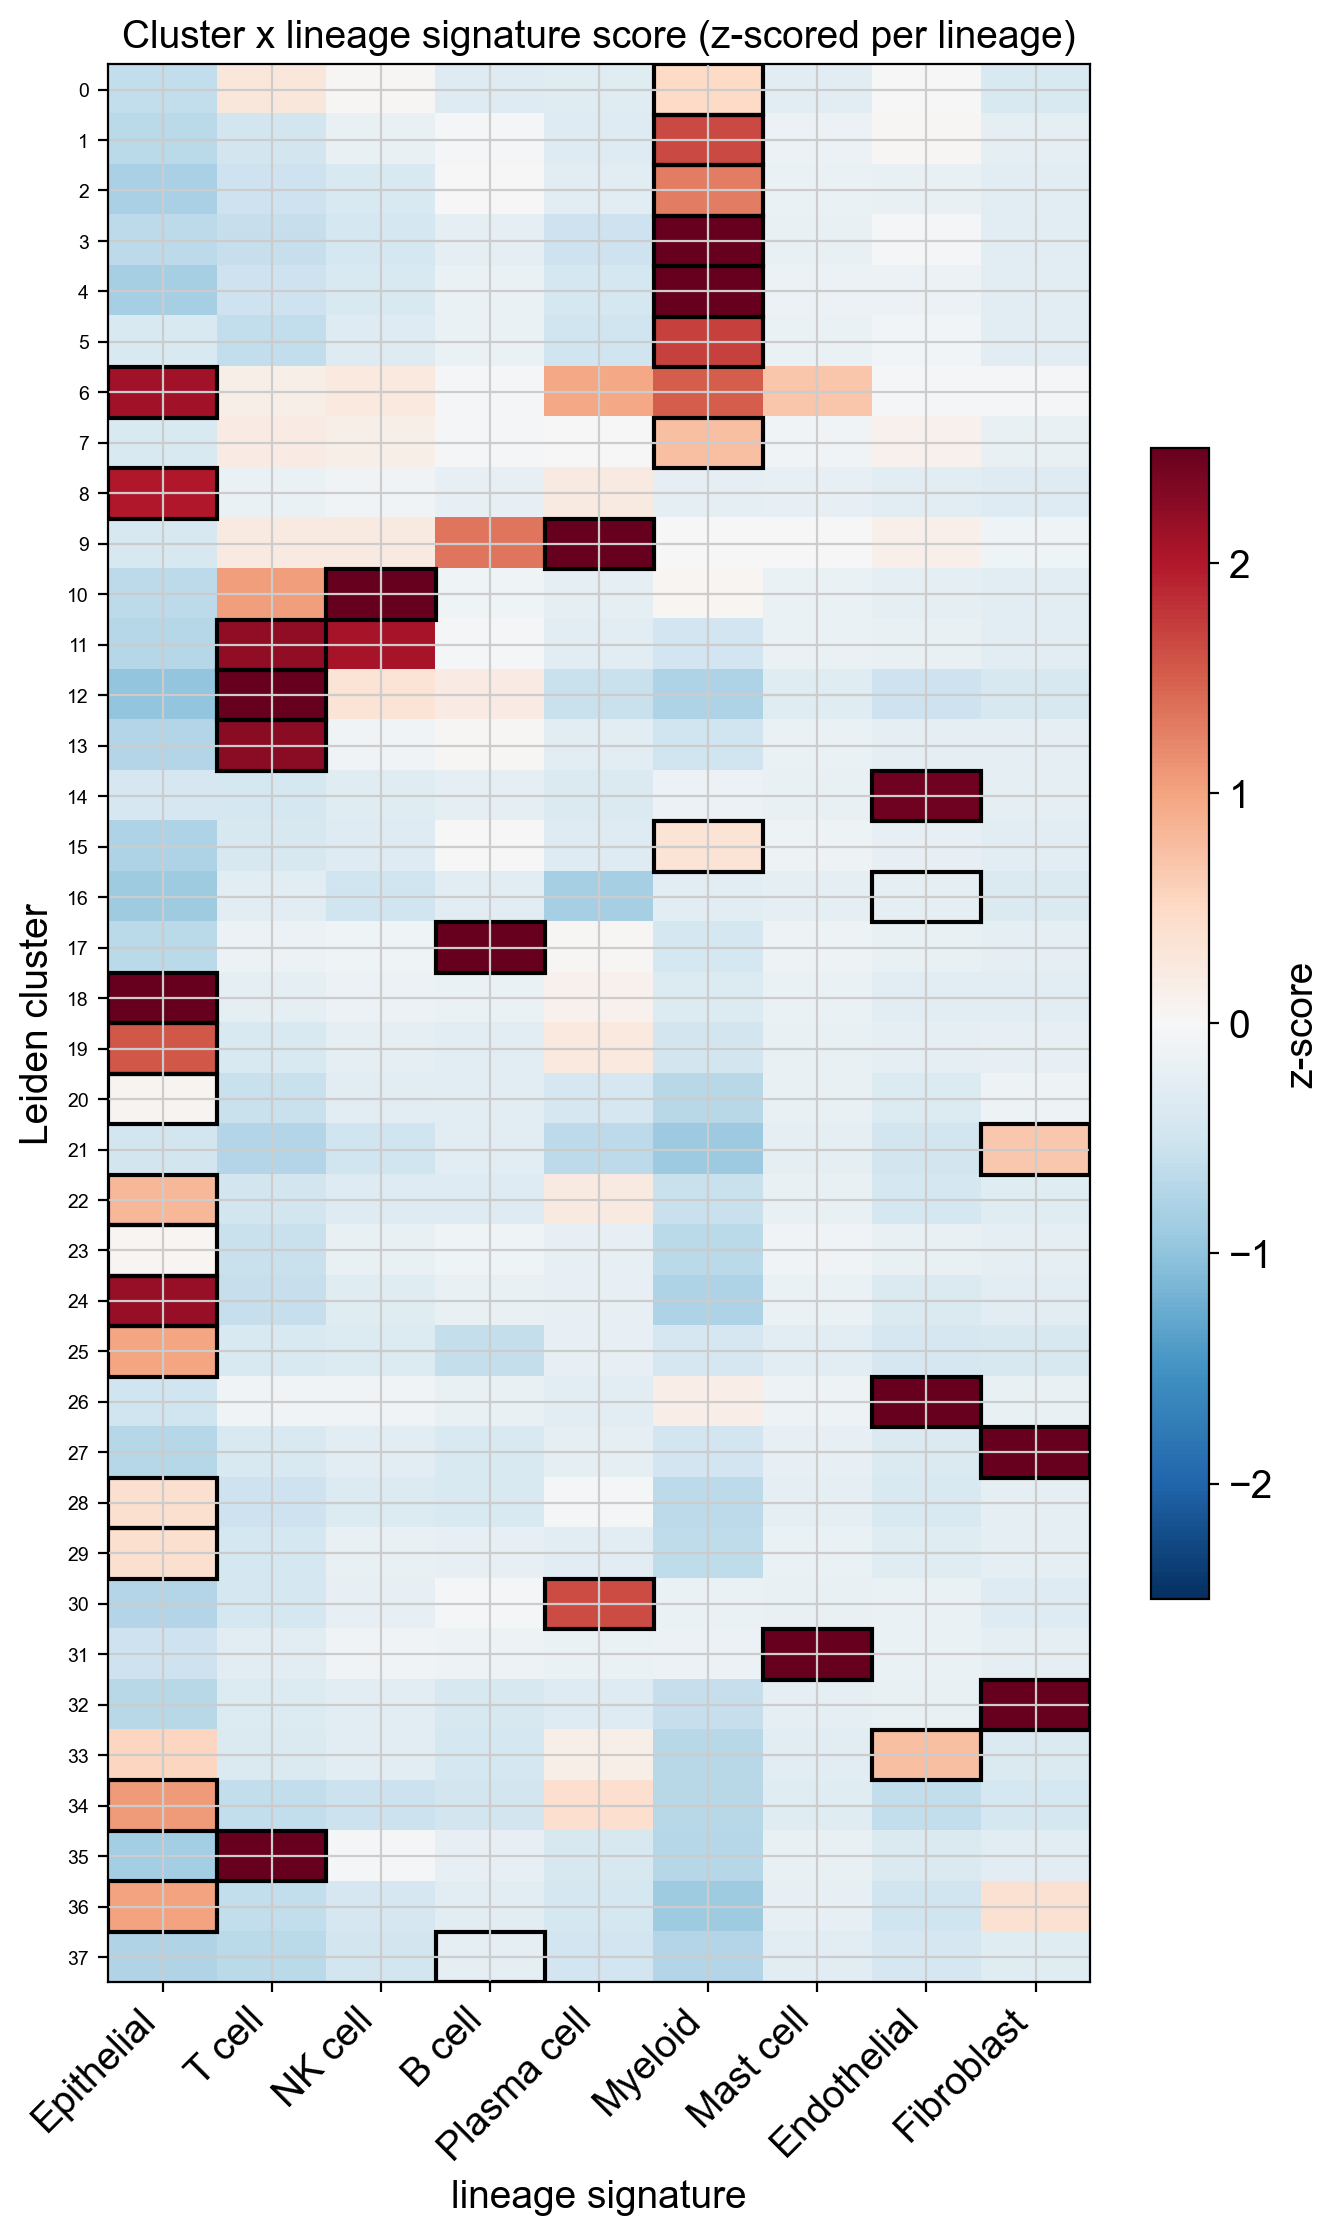

In [9]:
# Heatmap: cluster x lineage z-scores, with the argmax assignment boxed.
fig, ax = plt.subplots(figsize=(7, max(4, 0.30 * len(z))))
im = ax.imshow(z.values, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax.set_xticks(range(z.shape[1]))
ax.set_xticklabels(z.columns, rotation=45, ha="right")
ax.set_yticks(range(z.shape[0]))
ax.set_yticklabels(z.index, fontsize=7)
ax.set_xlabel("lineage signature")
ax.set_ylabel("Leiden cluster")
ax.set_title("Cluster x lineage signature score (z-scored per lineage)")
for r in range(z.shape[0]):
    c = int(np.argmax(z.values[r]))
    ax.add_patch(mpl.patches.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                       edgecolor="black", lw=1.5))
fig.colorbar(im, ax=ax, shrink=0.6, label="z-score")
fig.tight_layout()
fig.savefig(FIG_DIR / "celltype_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

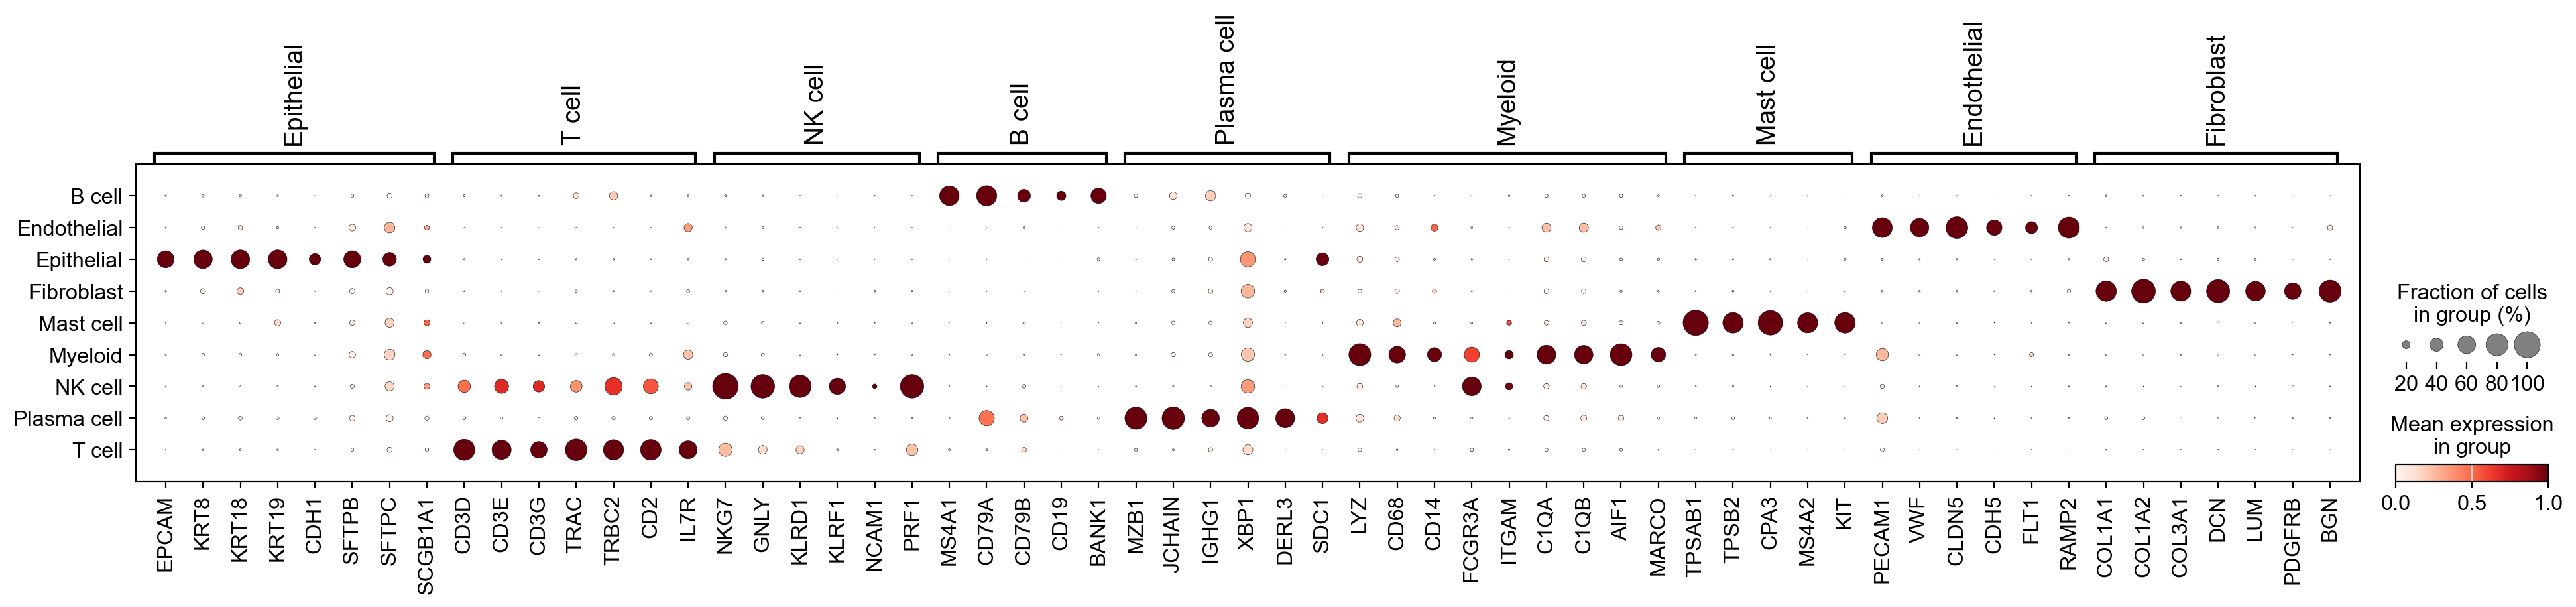

In [10]:
# Dotplot: do the assigned lineages actually express their canonical markers?
sc.pl.dotplot(
    adata, var_names=MARKERS_PRESENT, groupby="cell_type_pred",
    standard_scale="var", show=False,
)
plt.savefig(FIG_DIR / "marker_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
sc.pl.umap(
    adata, color="cell_type_pred", title="Predicted cell type",
    size=4, save="_celltype_pred.png", show=False,
)
plt.show()

## 6. Benchmark against LuCA's published labels

LuCA's `cell_type_major` is a **24-category** annotation (e.g. `T cell CD8`,
`Macrophage alveolar`, `cDC2`, `Alveolar cell type 2`). Our annotation is
deliberately coarse — nine lineages — so we first **harmonise** LuCA's 24
labels down onto those nine with an editable mapping dict, then compare.

Two metrics, both computed on the harmonised (coarse-vs-coarse) labels:

- **Overall agreement** — the fraction of cells on which our coarse label
  matches LuCA's harmonised coarse label.
- **Adjusted Rand Index (ARI)** — a chance-corrected measure of how well the
  two partitions agree. It must be computed coarse-vs-coarse: running it
  against LuCA's raw 24-category column understates agreement badly, because
  ARI penalises a granularity mismatch even when the coarse grouping is
  correct.

The mapping dict below is tuned to the 24 labels in this LuCA subsample. If
the printed `UNMAPPED` list contains anything other than `other` (LuCA's own
catch-all, intentionally left unmapped), extend the dict and rerun.

In [12]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# Harmonise LuCA's 24-category cell_type_major onto our 9 coarse lineages.
# Keys are lower-cased LuCA labels; this dict covers every label in this
# subsample. "other" is LuCA's catch-all and is intentionally absent - it
# stays unmapped and is excluded from the comparison.
PUBLISHED_TO_COARSE = {
    # epithelial: tumour cells + every normal-lung epithelial subtype
    "tumor cells": "Epithelial", "alveolar cell type 1": "Epithelial",
    "alveolar cell type 2": "Epithelial", "transitional club/at2": "Epithelial",
    "ciliated": "Epithelial", "club": "Epithelial",
    "epithelial cell": "Epithelial",
    # lymphoid
    "t cell cd8": "T cell", "t cell cd4": "T cell",
    "t cell regulatory": "T cell",
    "nk cell": "NK cell",
    "b cell": "B cell",
    "plasma cell": "Plasma cell",
    # myeloid: macrophages, monocytes, dendritic cells, neutrophils
    "macrophage": "Myeloid", "macrophage alveolar": "Myeloid",
    "monocyte": "Myeloid", "cdc1": "Myeloid", "cdc2": "Myeloid",
    "dc mature": "Myeloid", "pdc": "Myeloid", "neutrophils": "Myeloid",
    # other compartments
    "mast cell": "Mast cell",
    "endothelial cell": "Endothelial",
    "stromal": "Fibroblast",
}

def to_coarse(label):
    return PUBLISHED_TO_COARSE.get(str(label).strip().lower(), None)

adata.obs["cell_type_major_coarse"] = adata.obs["cell_type_major"].map(to_coarse)

unmapped = sorted(adata.obs.loc[
    adata.obs["cell_type_major_coarse"].isna(), "cell_type_major"
].astype(str).unique())
if unmapped:
    print(f"\nUNMAPPED published labels (add these to PUBLISHED_TO_COARSE): {unmapped}")
else:
    print("\nAll published labels harmonised onto the 9 coarse lineages.")


UNMAPPED published labels (add these to PUBLISHED_TO_COARSE): ['other']


In [13]:
# Compare on cells whose published label maps cleanly onto our 9 lineages.
mask = adata.obs["cell_type_major_coarse"].notna()
y_true = adata.obs.loc[mask, "cell_type_major_coarse"].astype(str)
y_pred = adata.obs.loc[mask, "cell_type_pred"].astype(str)

# ARI on the harmonised coarse labels (9-vs-9) - see the note above on why
# this must not be run against LuCA's raw 24-category column.
ari = adjusted_rand_score(y_true, y_pred)

labels = [l for l in MARKERS_PRESENT if l in set(y_true) | set(y_pred)]
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

overall_agree = float((y_true.values == y_pred.values).mean())
per_class = pd.Series(np.diag(cm_norm), index=labels, name="recall").round(3)

print(f"Cells compared:      {int(mask.sum()):,} / {adata.n_obs:,} "
      f"({mask.mean():.1%})")
print(f"Overall agreement:   {overall_agree:.1%}")
print(f"Adjusted Rand Index: {ari:.3f}  (coarse vs coarse)")
print(f"\nPer-lineage recall (fraction of each published label we recover):")
print(per_class.to_string())

metrics = pd.DataFrame({
    "metric": ["overall_agreement", "adjusted_rand_index",
               "n_cells_compared", "n_leiden_clusters"],
    "value": [round(overall_agree, 4), round(float(ari), 4),
              int(mask.sum()), int(n_clusters)],
})
metrics.to_csv(FIG_DIR / "annotation_metrics.csv", index=False)
print(f"\nWrote {relpath(FIG_DIR / 'annotation_metrics.csv')}")

Cells compared:      90,563 / 92,013 (98.4%)
Overall agreement:   95.2%
Adjusted Rand Index: 0.918  (coarse vs coarse)

Per-lineage recall (fraction of each published label we recover):
Epithelial     0.981
T cell         0.897
NK cell        0.858
B cell         0.978
Plasma cell    0.978
Myeloid        0.969
Mast cell      0.996
Endothelial    0.990
Fibroblast     0.997

Wrote figures\annotation_metrics.csv


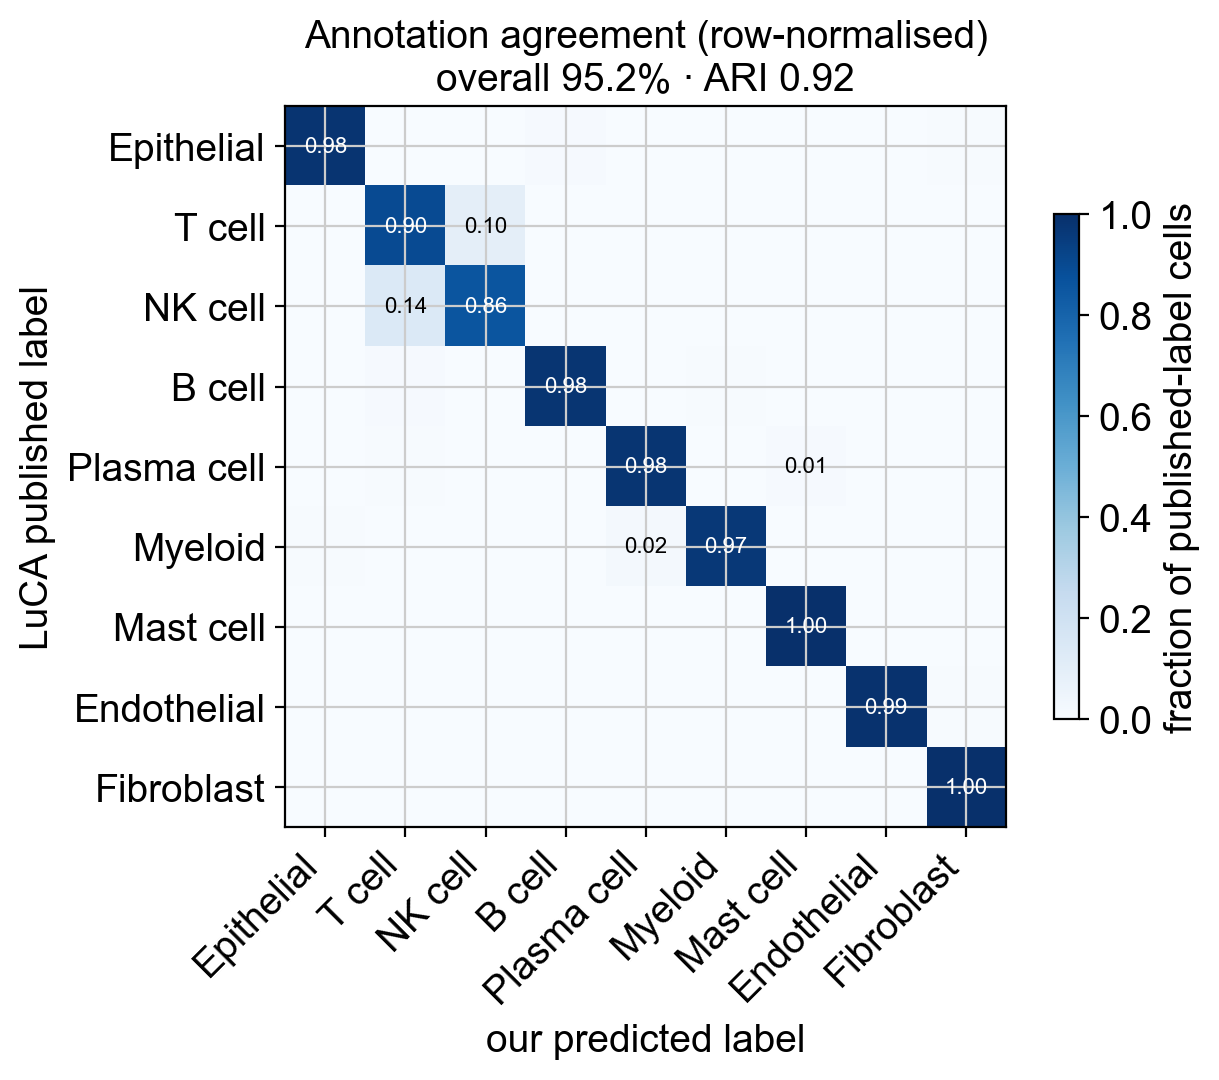

In [14]:
# Row-normalised confusion matrix: row = LuCA label, column = our label.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("our predicted label")
ax.set_ylabel("LuCA published label")
ax.set_title(f"Annotation agreement (row-normalised)\n"
             f"overall {overall_agree:.1%} · ARI {ari:.2f}")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm_norm[i, j]
        if v > 0.01:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.7, label="fraction of published-label cells")
fig.tight_layout()
fig.savefig(FIG_DIR / "annotation_confusion_matrix.png", dpi=150,
            bbox_inches="tight")
plt.show()

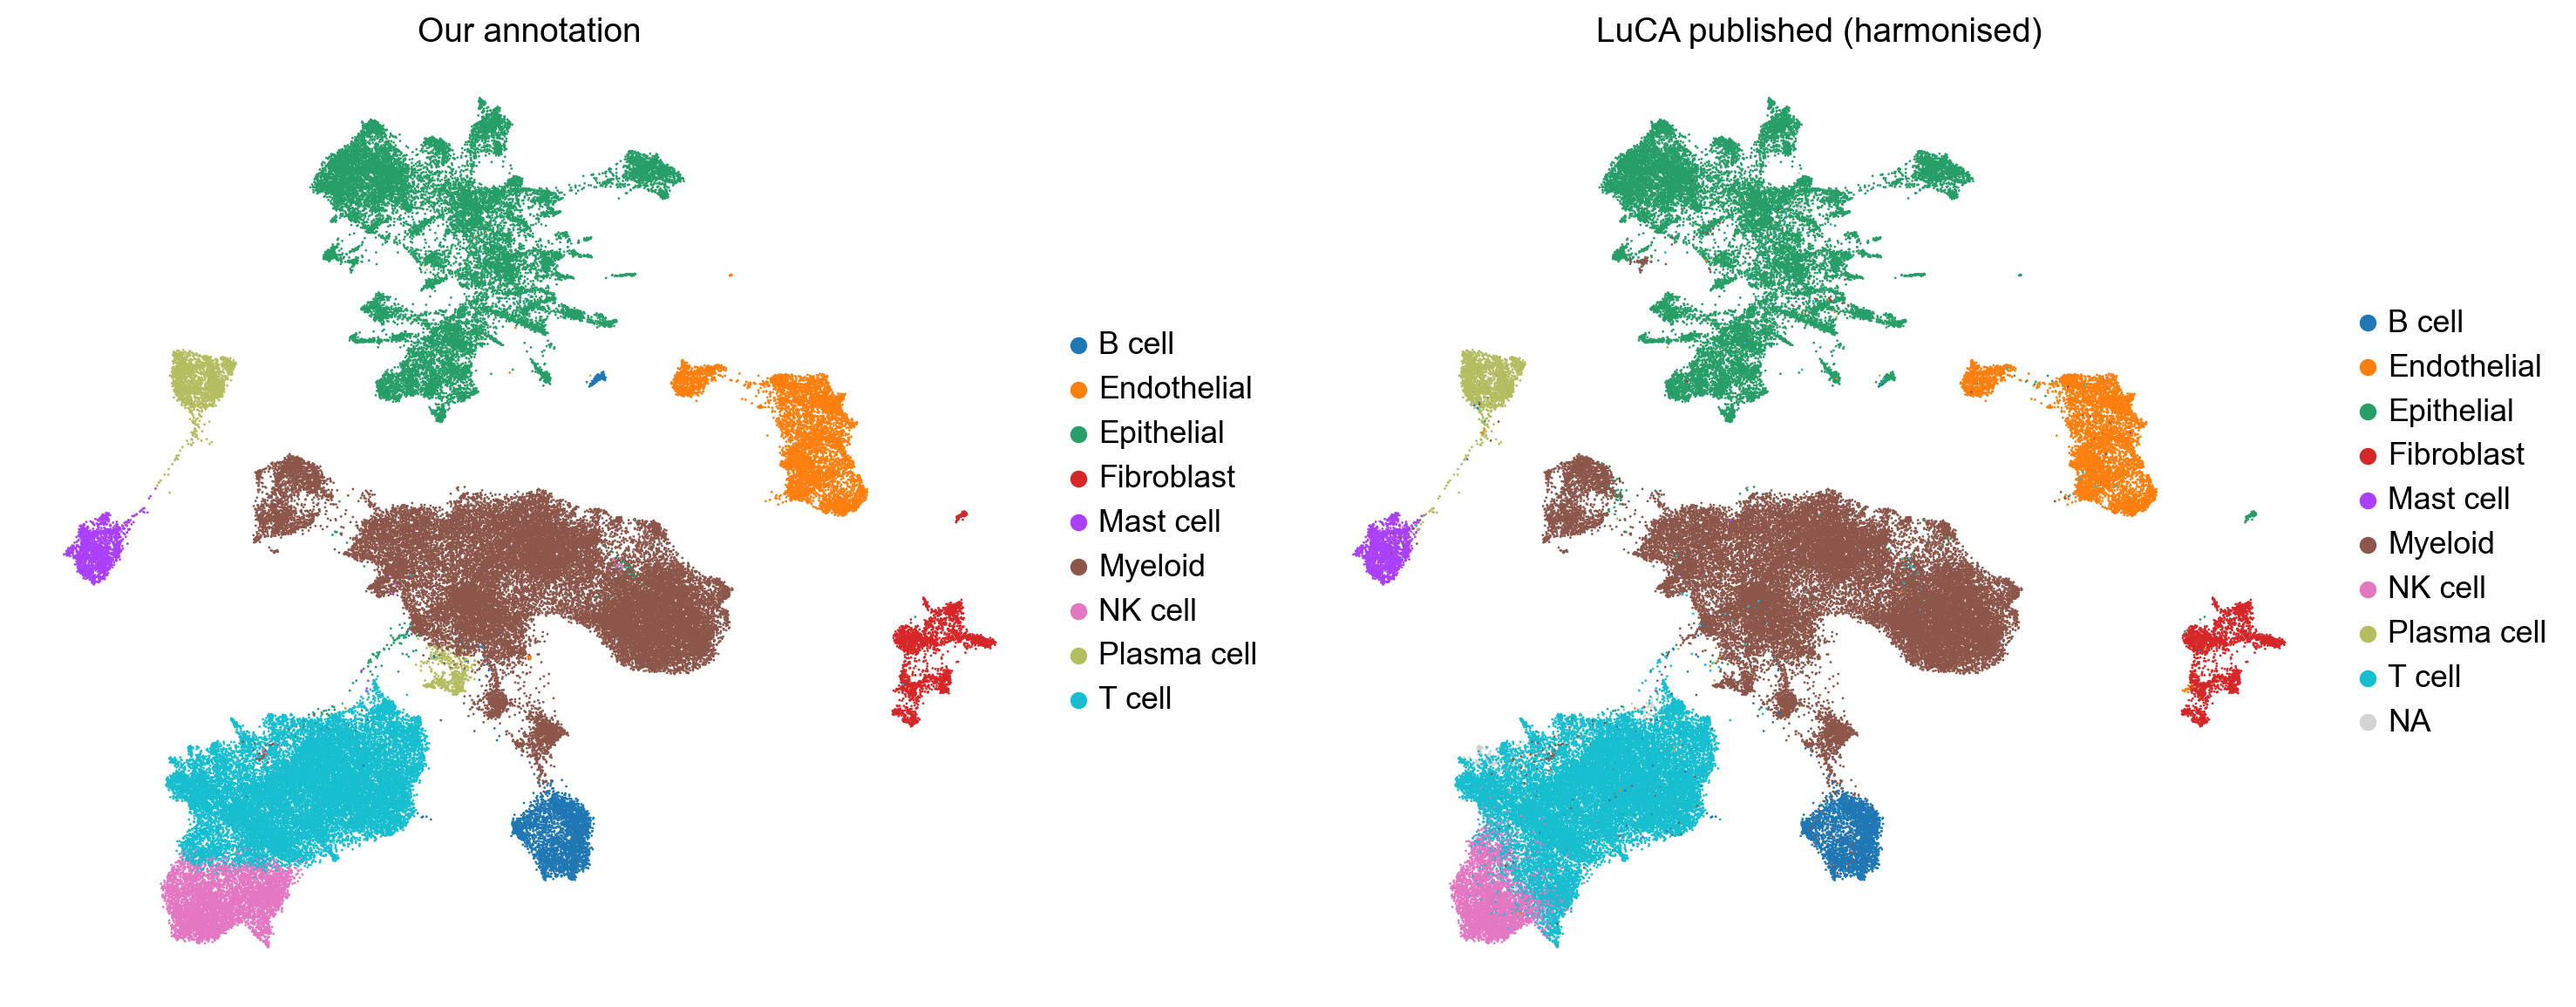

In [15]:
# Side-by-side UMAP: our annotation vs LuCA's harmonised labels.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(adata, color="cell_type_pred", ax=axes[0], show=False,
           title="Our annotation", size=4)
sc.pl.umap(adata, color="cell_type_major_coarse", ax=axes[1], show=False,
           title="LuCA published (harmonised)", size=4)
fig.tight_layout()
fig.savefig(FIG_DIR / "umap_annotation_compare.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 7. Save the annotated AnnData

The annotated object carries everything notebook 04 needs: `obs["leiden"]`,
`obs["cell_type_pred"]`, the harmonised benchmark column, and the per-lineage
`score_*` columns (kept because notebook 04 may reuse cell-state scores).

In [16]:
out_path = save_adata(adata, "processed/luca_annotated.h5ad")
print(f"Saved annotated AnnData to {relpath(out_path)}")
print(f"  size: {out_path.stat().st_size / 1e6:.0f} MB")
print(f"  obs added: leiden, cell_type_pred, cell_type_major_coarse, "
      f"{len(score_cols)} score_* columns")

Saved annotated AnnData to data\processed\luca_annotated.h5ad
  size: 1167 MB
  obs added: leiden, cell_type_pred, cell_type_major_coarse, 9 score_* columns


## Summary — Phase 3 complete

- Leiden-clustered the `X_scVI` neighbour graph into fine clusters
  (`resolution=1.0`).
- Scored every cell against nine canonical lineage signatures with
  `sc.tl.score_genes`.
- Assigned each cluster to a lineage via the per-cluster argmax of the
  z-scored signature matrix, and reported per-cluster confidence margins.
- Benchmarked against LuCA's published `cell_type_major`: confusion matrix,
  overall agreement, and Adjusted Rand Index.
- Saved `data/processed/luca_annotated.h5ad` and the benchmark figures.

**Honest limitations.** At `resolution=1.0` a rare lineage (e.g. NK cells)
can fail to win any cluster outright if it co-clusters with a related
lineage (T cells); if a lineage is missing from the predicted composition,
raise the resolution or sub-cluster the relevant T/NK clusters. Marker-score
fine subtypes; that is by design for this notebook, whose benchmark column
is itself coarse.

**Next:** [`04_compositional_analysis.ipynb`](04_compositional_analysis.ipynb)
— per-patient cell-type composition vectors and a LightGBM classifier
predicting LUAD vs LUSC histology with leave-one-study-out cross-validation.